In [234]:
import numpy as np
import matplotlib.pyplot as plt

# MLP - Multilayer perceptron  
class MLP_Network:
    def __init__(self, N_input=1, J_hidden=2, M_output=1, eta=0.3, epsilon=1e-3):
        self.N_input = N_input
        self.J_hidden = J_hidden
        self.M_output = M_output
        self.eta = eta  # Норма обучения
        self.epsilon = epsilon  # Порог ошибки
        
        # Инициализация весов (матрицы весов (rows, cols))
        # self.W_ij_hidden = np.random.uniform(0, 0.9, (J_hidden, N_input))  # Вход -> скрытый слой
        self.W_ij_hidden =  np.full((J_hidden, N_input), 0.5) 
        # self.W_ij_hidden = np.zeros((J_hidden, N_input))
        # N = 1, J = 2: W_ij_hidden = [[w1]
        #                              [w2]]

        # self.W_0j_hidden = np.zeros(J_hidden)  # Смещение скрытого слоя
        self.W_0j_hidden =  np.full(J_hidden, 0.5) 
        # self.W_0j_hidden = np.random.uniform(0, 0.9, J_hidden)
        
        # J = 2:        W_0j_hidden = [0. 0.]

        # self.W_jm_output = np.random.uniform(0, 0.9, (M_output, J_hidden))  # Скрытый -> выход
        self.W_jm_output =  np.full((M_output, J_hidden), 0.5) 
        # self.W_jm_output = np.zeros((M_output, J_hidden))
        # J = 2, M = 1: W_jm_output = [w11 w22]

        # self.W_0m_output = np.zeros(M_output)  # Смещение выходного слоя
        self.W_0m_output =  np.full(M_output, 0.5) 
        # self.W_0m_output = np.random.uniform(0, 0.9, M_output)
        # M = 1:        W_0m_output = [0.]
    
    def activation(self, net):
        # ФА скрытого и выходного слоев (Гиперболический тангенс)
        return (1 - np.exp(-net)) / (1 + np.exp(-net))
    
    def activation_derivative(self, net):
        # Производная ФА
        return 0.5 * (1 - self.activation(net) ** 2)
    
    def forward(self, x):
        # Прямое распространение ---------- ЭТАП 1
        self.net_hidden = np.dot(self.W_ij_hidden, x) + self.W_0j_hidden
        self.out_hidden = self.activation(self.net_hidden)
        self.net_output = np.dot(self.W_jm_output, self.out_hidden) + self.W_0m_output
        self.out_output = self.activation(self.net_output)
        return self.out_output
    
    def backward(self, x, target):
        # Обратное распространение ошибки - ЭТАП 2
        output_error = target - self.out_output  # Ошибка на выходе
        output_delta = output_error * self.activation_derivative(self.net_output)
        
        hidden_error = np.dot(self.W_jm_output.T, output_delta)
        hidden_delta = hidden_error * self.activation_derivative(self.net_hidden)
        
        # Обновление весов ---------------- ЭТАП 3
        self.W_jm_output += self.eta * np.outer(output_delta, self.out_hidden)
        self.W_0m_output += self.eta * output_delta

        self.W_ij_hidden += self.eta * np.outer(hidden_delta, x)
        self.W_0j_hidden += self.eta * hidden_delta
        
        # Примечание: np.outer(A, B) вычисляет внешнее произведение двух одномерных массивов
        # outer(A,B) = A * B.T
        # A = np.array([1, 2, 3]) 
        # B = np.array([4, 5]) -> np.outer(A, B):
        # [[ 4  5]
        #  [ 8 10]
         # [12 15]]
        return np.sqrt(np.sum(output_error ** 2))  # Среднеквадратичная ошибка
    
    def train(self, inputs, targets, max_epochs=1000):
        
        header = f"{'Epoch':<6} | {'Target t':<9} | {'Output y':<8} | {'Error E(k)':<10} | {'W_ij_hidden':<46} | {'W_jm_output':<20}"
        print(header)
        error_history = []

        for epoch in range(1, max_epochs + 1):
            total_error = 0
            initial_W_ij_hidden = np.copy(self.W_ij_hidden)
            initial_W_jm_output = np.copy(self.W_jm_output)
            initial_W_0j_hidden = np.copy(self.W_0j_hidden)
            initial_W_0m_output = np.copy(self.W_0m_output)
            for x, target in zip(inputs, targets):
                self.forward(x)
                total_error += self.backward(x, target) 
            
            error_history.append(total_error)
            
            weights_ij = np.concatenate([initial_W_0j_hidden, initial_W_ij_hidden.flatten()])
            weights_jm = np.concatenate([initial_W_0m_output, initial_W_jm_output.flatten()])
            weights_ij_rounded = [f"{w:.5f}" for w in weights_ij]
            weights_jm_rounded = [f"{w:.5f}" for w in weights_jm]
            # Вывод строки таблицы
            print(f"{epoch:6d} | {target[0]:9.1f} | {self.out_output[0]:8.5f} | {total_error:11.5f} | {weights_ij_rounded} | {weights_jm_rounded}")
            
            if total_error <= self.epsilon:
                break
        return error_history

N = 1, J = 2, M = 1
x = [1 2]
t = [-0.3]
eta = 0.3
Epoch  | Target t  | Output y | Error E(k) | W_ij_hidden                                    | W_jm_output         
     1 |      -0.3 |  0.44709 |     0.74709 | ['0.50000', '0.50000', '0.50000', '0.50000'] | ['0.50000', '0.50000', '0.50000']
     2 |      -0.3 |  0.38904 |     0.68904 | ['0.48237', '0.48237', '0.48237', '0.48237'] | ['0.41034', '0.45857', '0.45857']
     3 |      -0.3 |  0.33084 |     0.63084 | ['0.46630', '0.46630', '0.46630', '0.46630'] | ['0.32262', '0.41926', '0.41926']
     4 |      -0.3 |  0.27403 |     0.57403 | ['0.45198', '0.45198', '0.45198', '0.45198'] | ['0.23835', '0.38258', '0.38258']
     5 |      -0.3 |  0.21986 |     0.51986 | ['0.43948', '0.43948', '0.43948', '0.43948'] | ['0.15872', '0.34885', '0.34885']
     6 |      -0.3 |  0.16924 |     0.46924 | ['0.42874', '0.42874', '0.42874', '0.42874'] | ['0.08451', '0.31819', '0.31819']
     7 |      -0.3 |  0.12269 |     0.42269 | ['0.41964', '0.41964', '0.

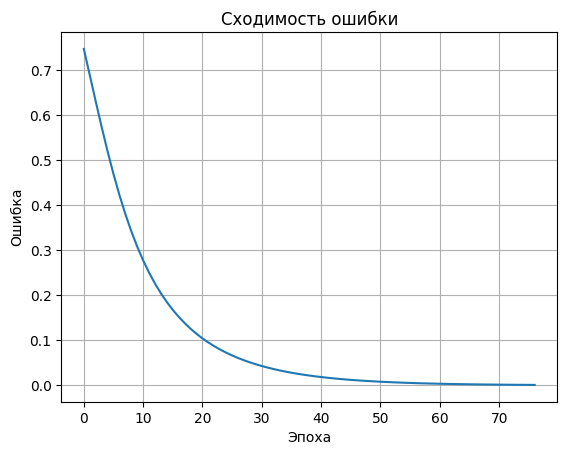

In [235]:
# Тестовые данные
inputs = np.array([[1], [2]])
# targets = np.array([[-0.3], [-0.3]])
targets = np.array([[-0.3]])
N_input=1  # число входов скрытого слоя  
J_hidden=2 # число нейронов скрытого слоя
M_output=1 # число нейронов выходного слоя
eta=0.3
epsilon=1e-3
print(f"N = {N_input}, J = {J_hidden}, M = {M_output}")
print(f"x = {inputs.flatten()}")
print(f"t = {targets.flatten()}")
print(f"eta = {eta}")
mlp = MLP_Network(N_input, J_hidden, M_output, eta, epsilon)
error_history = mlp.train(inputs, targets, max_epochs=1000)

# График ошибки
plt.plot(error_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Сходимость ошибки")
plt.grid()
plt.show()